In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import shutil
import os

In [4]:
shutil.unpack_archive("data.zip", "data")
os.listdir("data/data")

['data_2d.csv', 'mnist.csv', '.ipynb_checkpoints']

In [10]:
data_2d = pd.read_csv("data/data/data_2d.csv")
mnist = pd.read_csv("data/data/mnist.csv", header=None)

print(data_2d.head())
print("------------------------------")
print(mnist.head())

   0.000000000000000000e+00  -7.687164597386728637e-01  \
0                       0.0                   2.687848   
1                       0.0                  -0.201379   
2                       0.0                   0.608496   
3                       0.0                  -0.082282   
4                       0.0                   2.083069   

   4.608603078297135447e-01  
0                  2.366961  
1                  0.470430  
2                  1.225400  
3                  1.137218  
4                  2.694482  
------------------------------
   7  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.658  0.659  0.660  \
0  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  4  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  1  0    0    0    0    0    0    0    0    0  ...   

Index(['7', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8'], dtype='object')

In [11]:
X_2d = data_2d.iloc[:, 1:]
X_mnist = mnist.iloc[:, 1:]

## 2d Датасет

### Ліктевий метод для 2d датасету

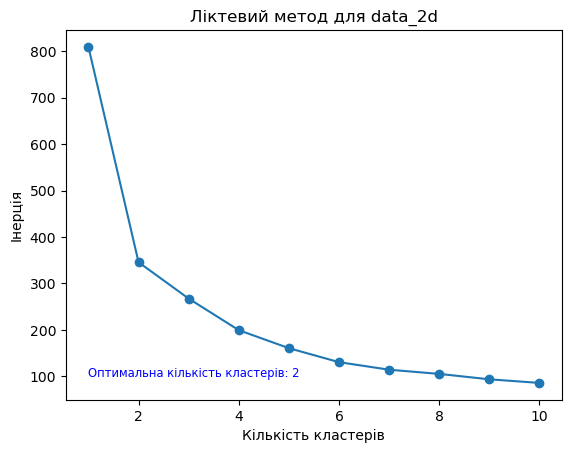

In [20]:
inertias_2d = []
clusters_2d = []
for k in range(1, 11):
    model = KMeans(n_clusters = k, random_state=42)
    model.fit(X_2d)
    inertias_2d.append(model.inertia_)
    clusters_2d.append(k)
plt.plot(clusters_2d, inertias_2d, marker="o")
plt.xlabel("Кількість кластерів")
plt.ylabel("Інерція")
plt.title("Ліктевий метод для data_2d")
plt.text(clusters_2d[0], 100, 'Оптимальна кількість кластерів: 2', fontsize='small', color="blue")
plt.show()   

### Навчання моделі та візуалізація кластерів

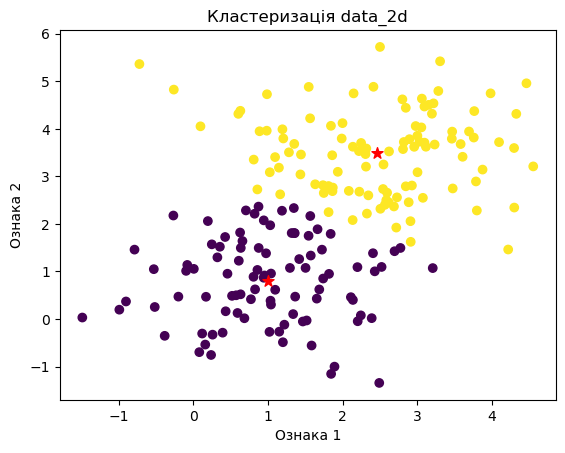

In [48]:
kmeans_2d = KMeans(n_clusters=2, random_state=42)
kmeans_2d.fit(X_2d)

plt.scatter(X_2d.iloc[:, 0], X_2d.iloc[:, 1], c=kmeans_2d.labels_)
plt.scatter(kmeans_2d.cluster_centers_[:, 0], kmeans_2d.cluster_centers_[:, 1], s=70, c="red", marker="*")
plt.xlabel("Ознака 1")
plt.ylabel("Ознака 2")
plt.title("Кластеризація data_2d")
plt.show()


## Mnist датасет

### Ліктевий метод для mnist датасету

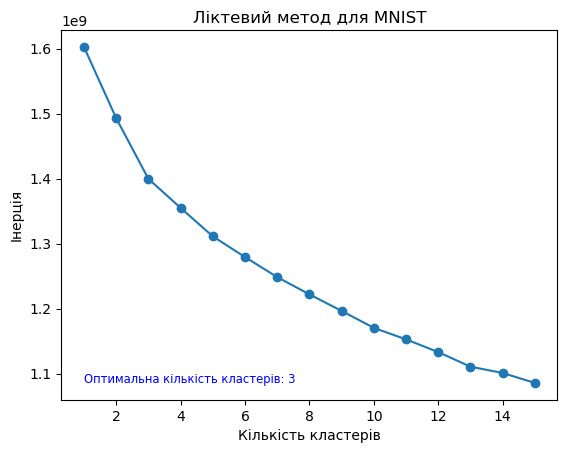

In [41]:
inertias_mnist = []
clusters_mnist = []

for k in range(1, 16):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_mnist)
    inertias_mnist.append(model.inertia_)
    clusters_mnist.append(k)

plt.plot(clusters_mnist, inertias_mnist, marker="o")
plt.xlabel("Кількість кластерів")
plt.ylabel("Інерція")
plt.title("Ліктевий метод для MNIST")
plt.text(clusters_mnist[0], inertias_mnist[-1], "Оптимальна кількість кластерів: 3", fontsize="small", color="blue")
plt.show()    

### Навчання моделі, PCA та візуалізація кластерів

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


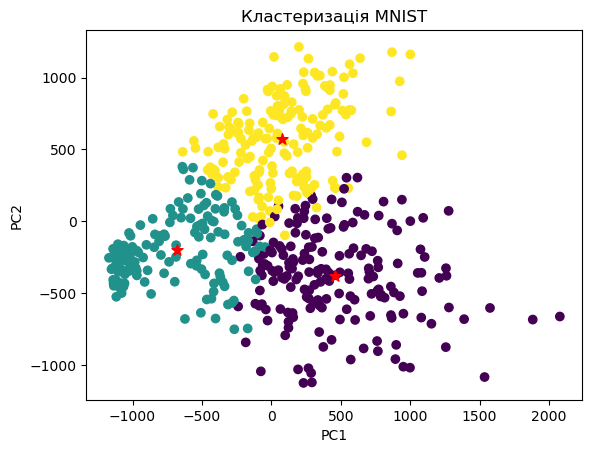

In [47]:
kmeans_mnist = KMeans(n_clusters=3, random_state=42)
kmeans_mnist.fit(X_mnist)

pca = PCA(n_components=2)
X_mnist_pca = pca.fit_transform(X_mnist)
centers = pca.transform(kmeans_mnist.cluster_centers_)

plt.scatter(
    X_mnist_pca[:, 0],
    X_mnist_pca[:, 1],
    c=kmeans_mnist.labels_,
)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=70,
    c="red",
    marker="*"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Кластеризація MNIST")
plt.show()

(499, 784)
(499, 2)
